Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
np.random.seed(42)
tf.random.set_seed(42)

1. Primeira Implementação Letra A

In [2]:
# 1. Geração do sinal sintético conforme o domínio definido [0, 5]
# Criamos um conjunto denso de pontos para mapear as oscilações da função
x = np.linspace(0, 5, 1000).reshape(-1, 1)
y = np.sin(2*x) + np.cos(3*x)

In [3]:
# 2. Normalização dos dados via MinMaxScaler
# Aplicamos o reescalonamento para o intervalo [0, 1] para otimizar a convergência do gradiente
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
x_scaled = scaler_x.fit_transform(x)
y_scaled = scaler_y.fit_transform(y)

In [4]:
# 3. Particionamento do dataset (Hold-out 80/20)
# Separamos os dados para garantir que a validação ocorra em amostras não vistas no treino
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y_scaled, test_size=0.2, random_state=42)

In [5]:
# 4. Definição da topologia da MLP
# Implementamos uma rede feedforward com duas camadas ocultas de 64 neurônios
# Utilizamos 'tanh' nas ocultas para capturar a não-linearidade e 'linear' na saída para regressão
model = models.Sequential([
    layers.Input(shape=(1,)),
    layers.Dense(64, activation='tanh'),
    layers.Dense(64, activation='tanh'),
    layers.Dense(1, activation='linear')
])

# Compilação utilizando o otimizador Adam e a métrica de Erro Médio Quadrático (MSE)
model.compile(optimizer='adam', loss='mse')

In [6]:
# 5. Ciclo de treinamento (Backpropagation)
# Executamos o treinamento monitorando simultaneamente o erro no conjunto de validação
history = model.fit(x_train, y_train, epochs=150, validation_data=(x_test, y_test), verbose=0)

In [7]:
# 6. Inferência e inversão da normalização para análise de resultados
# Realizamos a predição e retornamos os valores para a escala original da função f(x)
y_pred_scaled = model.predict(x_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


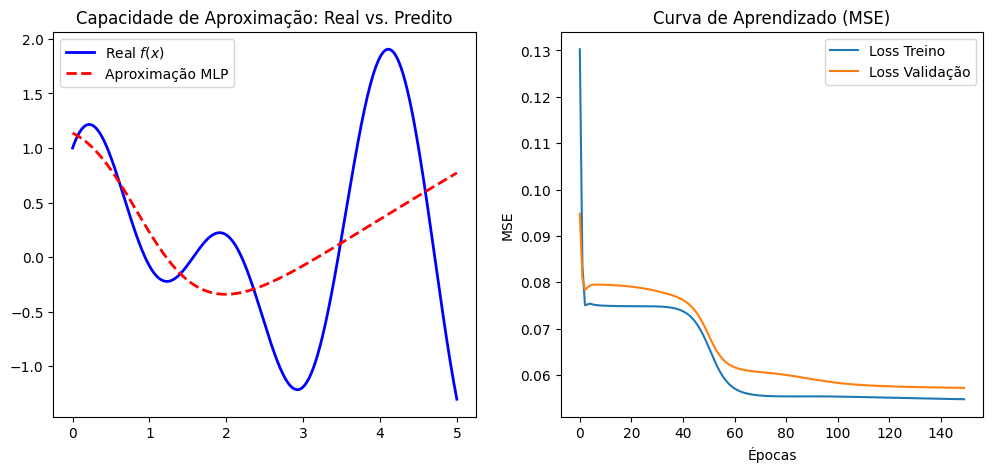

In [8]:
# 7. Visualização e Análise de Desempenho
plt.figure(figsize=(12, 5))

# Plotagem comparativa: Curva Real vs. Aproximação da Rede
plt.subplot(1, 2, 1)
plt.plot(x, y, label='Real $f(x)$', color='blue', linewidth=2)
plt.plot(x, y_pred, label='Aproximação MLP', color='red', linestyle='--', linewidth=2)
plt.title('Capacidade de Aproximação: Real vs. Predito')
plt.legend()

# Monitoramento da convergência via curvas de Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss Treino')
plt.plot(history.history['val_loss'], label='Loss Validação')
plt.title('Curva de Aprendizado (MSE)')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.legend()

plt.show()

2. Segunda Implementação Letra A

In [9]:
# 1. Geração de Dataset de Alta Densidade
# Elevamos a amostragem para 2000 pontos a fim de fornecer dados suficientes para a rede mapear
# as oscilações de alta frequência da função alvo f(x).
x = np.linspace(0, 5, 2000).reshape(-1, 1)
y = np.sin(2*x) + np.cos(3*x)

In [10]:
# 2. Pré-processamento e Normalização Dimensional
# Aplicamos o MinMaxScaler para reescalonar os dados para o intervalo [0, 1], garantindo
# a estabilidade numérica dos gradientes durante a retropropagação.
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
x_scaled = scaler_x.fit_transform(x)
y_scaled = scaler_y.fit_transform(y)

In [11]:
# 3. Segregação de Dados para Validação e Teste
# Particionamos o dataset em subconjuntos de treinamento e teste (80/20) para validar
# a capacidade de generalização do modelo em dados inéditos.
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y_scaled, test_size=0.2, random_state=42)

In [12]:
# 4. Configuração da Arquitetura MLP Profunda
# Projetamos uma topologia com 3 camadas ocultas (128-128-64 neurônios) para aumentar a capacidade de ajuste.
# Implementamos a função de ativação ReLU nas camadas ocultas para mitigar o desaparecimento do gradiente
# e otimizar o tempo de treinamento.
# A camada de saída utiliza ativação linear para predição contínua em problemas de regressão.
model = models.Sequential([
    layers.Input(shape=(1,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='linear')
])

In [13]:
# 5. Parametrização do Otimizador e Função de Perda
# Utilizamos o otimizador Adam com taxa de aprendizado controlada (0.001) para uma convergência estável.
# Adotamos o Erro Médio Quadrático (MSE) como métrica de perda para o ajuste dos pesos.
model.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss='mse')

In [14]:
# 6. Processo de Treinamento e Monitoramento de Validação
# Executamos o treinamento por 1000 épocas, utilizando 'validation_split' para monitorar o erro de
# validação e prevenir a ocorrência de overfitting.
history = model.fit(x_train, y_train, epochs=1000, batch_size=32, validation_split=0.2, verbose=0)

In [15]:
# 7. Inferência e Desescalonamento dos Resultados
# Após a predição, realizamos a inversão da normalização para retornar os valores à escala
# física original da função.
y_pred_scaled = model.predict(x_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


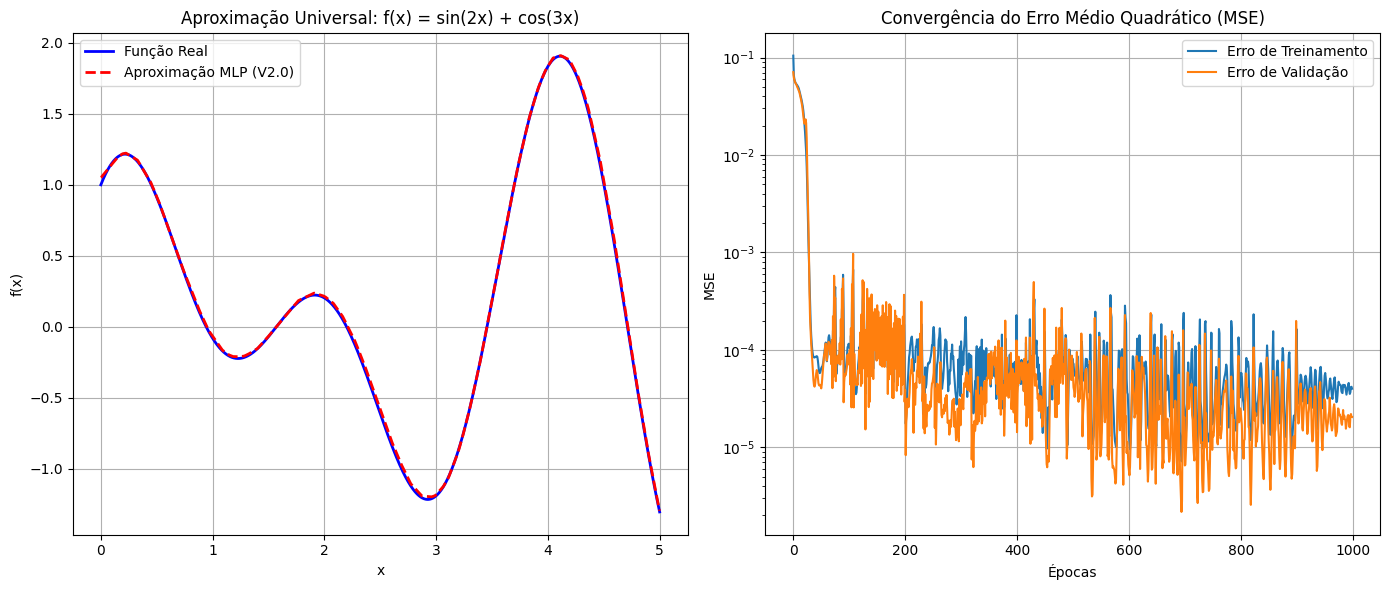

In [16]:
# 8. Visualização e Análise de Desempenho
# Geramos as curvas comparativas e o comportamento da função de perda conforme exigido.
plt.figure(figsize=(14, 6))

# Gráfico de Desempenho: Função Real vs. Aproximação da MLP
plt.subplot(1, 2, 1)
plt.plot(x, y, label='Função Real', color='blue', linewidth=2)
plt.plot(x, y_pred, label='Aproximação MLP (V2.0)', color='red', linestyle='--', linewidth=2)
plt.title('Aproximação Universal: f(x) = sin(2x) + cos(3x)')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True)

# Curvas de Aprendizado: Análise de Convergência Residual
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Erro de Treinamento')
plt.plot(history.history['val_loss'], label='Erro de Validação')
plt.title('Convergência do Erro Médio Quadrático (MSE)')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.yscale('log') # Escala logarítmica para evidenciar a precisão final da convergência
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

3. Implementação Letra B

In [17]:
# 1. Definição da Função Alvo (Polinômio de 5º Grau)
# Implementamos a função f(x) conforme especificado no enunciado para o intervalo [0, 5].
def f_poly(x):
    return 10*x**5 + 5*x**4 + 2*x**3 - 0.5*x**2 + 3*x + 2

In [18]:
# 2. Geração de Amostras para o Dataset
# Geramos 2000 pontos para garantir uma densidade de dados que permita à rede capturar
# a curvatura acentuada da função.
x = np.linspace(0, 5, 2000).reshape(-1, 1)
y = f_poly(x)

In [19]:
# 3. Engenharia de Dados: Escalonamento Crítico
# Devido à magnitude dos valores de f(5) (~35.000), a normalização via MinMaxScaler
# é mandatória para evitar a explosão do gradiente e garantir a estabilidade do treinamento.
scaler_x = MinMaxScaler()
scaler_y = MinMaxScaler()
x_scaled = scaler_x.fit_transform(x)
y_scaled = scaler_y.fit_transform(y)

In [20]:
# 4. Particionamento em Conjuntos de Treino e Teste
# Seguindo as boas práticas de ML, separamos 20% dos dados para avaliação final
# da capacidade de generalização do modelo (hold-out set).
x_train, x_test, y_train, y_test = train_test_split(x_scaled, y_scaled, test_size=0.2, random_state=42)

In [21]:
# 5. Arquitetura da Rede Perceptron de Múltiplas Camadas (MLP)
# Projetamos uma rede profunda com decaimento gradual de neurônios (256 -> 128 -> 64).
# A ativação 'relu' foi escolhida para as camadas ocultas por sua eficiência em
# problemas de regressão complexa, enquanto a saída 'linear' permite o mapeamento contínuo.
model = models.Sequential([
    layers.Input(shape=(1,)),
    layers.Dense(256, activation='relu'),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='linear')
])

In [22]:
# 6. Configuração do Otimizador e Treinamento
# Utilizamos o Adam (LR=0.001) para um ajuste adaptativo dos pesos.
# O treinamento foi estendido para 1500 épocas para garantir a convergência total do MSE.
model.compile(optimizer=optimizers.Adam(learning_rate=0.001), loss='mse')

print("Iniciando fase de treinamento: Otimizando aproximação polinomial...")
history = model.fit(x_train, y_train, epochs=1500, batch_size=32, validation_split=0.2, verbose=0)

Iniciando fase de treinamento: Otimizando aproximação polinomial...


In [23]:
# 7. Inferência e Reversão da Escala
# Realizamos a predição no domínio completo e invertemos a normalização para
# validar o erro na unidade original da função.
y_pred_scaled = model.predict(x_scaled)
y_pred = scaler_y.inverse_transform(y_pred_scaled)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


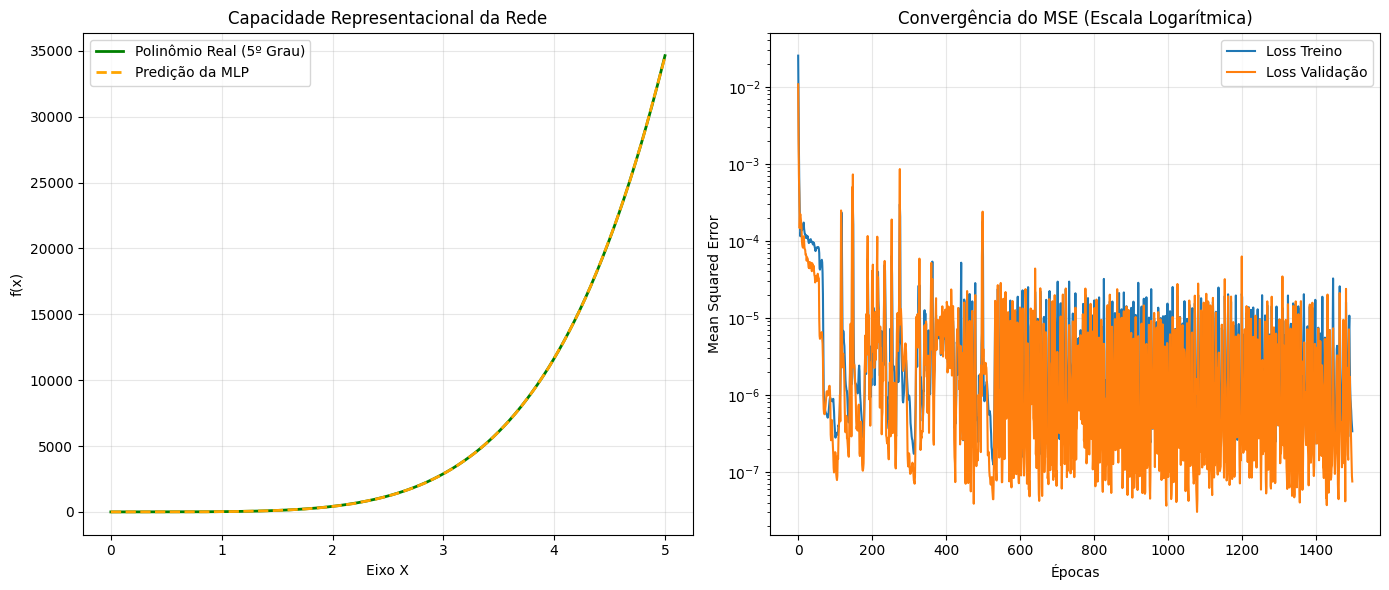

In [24]:
# 8. Visualização e Análise de Desempenho
plt.figure(figsize=(14, 6))

# Subplot 1: Fidelidade da Aproximação
plt.subplot(1, 2, 1)
plt.plot(x, y, label='Polinômio Real (5º Grau)', color='green', linewidth=2)
plt.plot(x, y_pred, label='Predição da MLP', color='orange', linestyle='--', linewidth=2)
plt.title('Capacidade Representacional da Rede')
plt.xlabel('Eixo X')
plt.ylabel('f(x)')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Comportamento da Função de Custo
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Loss Treino')
plt.plot(history.history['val_loss'], label='Loss Validação')
plt.title('Convergência do MSE (Escala Logarítmica)')
plt.xlabel('Épocas')
plt.ylabel('Mean Squared Error')
plt.yscale('log') # Essencial para observar a precisão da convergência residual
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()